# VaR 风险测算 - 定增项目

## 分析目标
使用多种方法计算定增项目的风险价值 (VaR)，包括：
- 历史模拟法
- 方差-协方差法（参数法）
- 蒙特卡洛法
- CVaR（条件风险价值）
- 最大回撤分析

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 配置中文字体
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ VaR风险测算模块加载成功')

✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ VaR风险测算模块加载成功


## 1. 参数设置

In [2]:
# ============================================================
# 加载定增分析配置（使用真实数据）
# ============================================================
from utils.config_loader import load_placement_config, print_config_summary
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 加载配置（自动尝试使用真实市场数据）
print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

# 风险参数（使用真实历史波动率）
RISK_PARAMS = {
    'volatility': risk_params['volatility'],  # 使用历史波动率
    'confidence_levels': [0.90, 0.95, 0.99],
    'drift': risk_params['drift']
}

正在加载配置...
✅ 已加载定增参数: ../300735_SZ_placement_params.json
✅ 已加载市场数据: ../300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%


## 2. 历史模拟法 VaR

=== 历史模拟法 VaR（单边）===
说明：95% VaR表示有95%的概率损失不会超过这个值（即5%的极端情况）
90% VaR: nan%
95% VaR: nan%
99% VaR: nan%


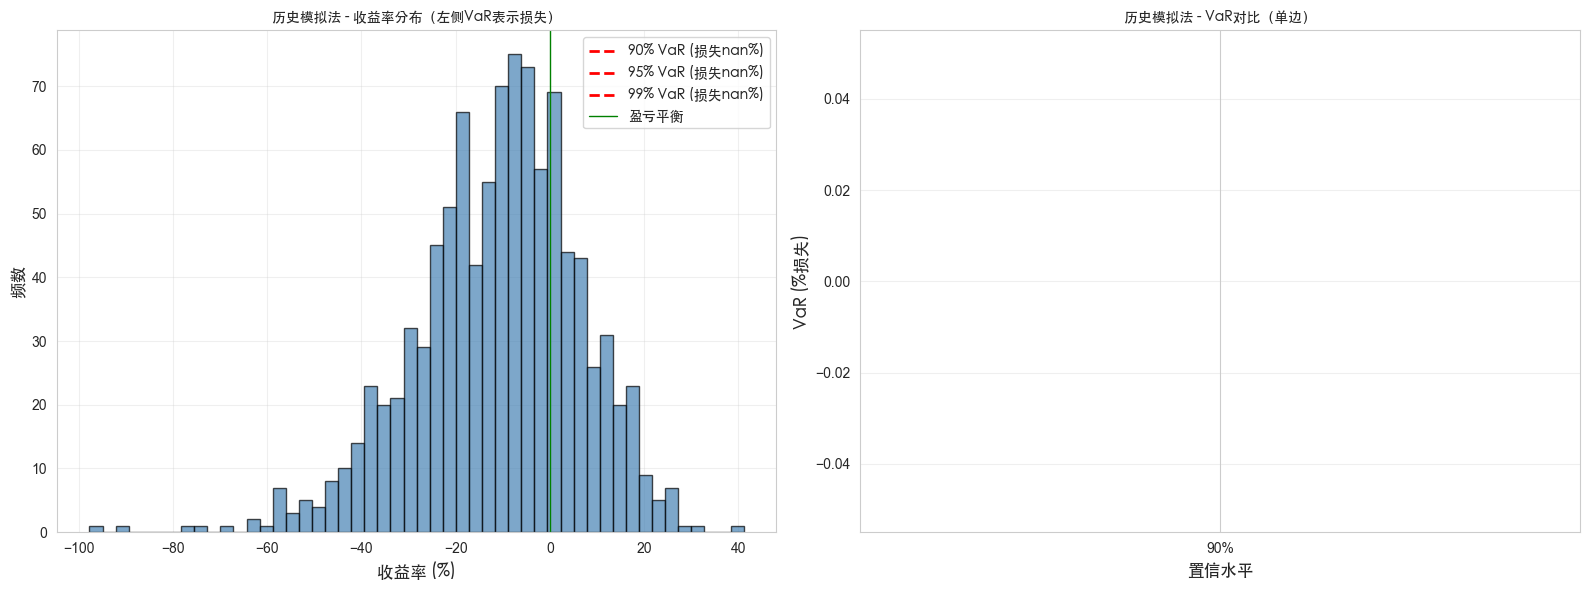

In [3]:
# 生成历史收益率样本（模拟）
np.random.seed(42)
n_samples = 1000

# 模拟历史收益率（假设正态分布）
# 注意：这里的收益率是年化收益率
historical_returns = np.random.normal(
    loc=RISK_PARAMS['drift'],  # 使用真实漂移率
    scale=RISK_PARAMS['volatility'],
    size=n_samples
)

# 计算定增收益率（锁定期收益）
lockup_return = (1 + historical_returns) ** (project_params['lockup_period'] / 12) - 1

# 计算VaR（单边置信度）
# VaR定义：在给定置信水平下，投资组合可能遭受的最大损失
# 95% VaR = 5%分位数（有5%的概率损失会超过这个值）
# 99% VaR = 1%分位数（有1%的概率损失会超过这个值）
historical_var = {}
for cl in RISK_PARAMS['confidence_levels']:
    # 单边VaR：取 (1-cl) 分位数，表示有 (1-cl)*100% 的概率会损失更多
    var_percentile = (1 - cl) * 100  # 例如：95%置信度 -> 5%分位数
    var_value = np.percentile(lockup_return, var_percentile)
    
    # VaR取绝对值，表示最大损失幅度
    # 如果var_value是正数，说明即使是最坏情况也盈利，VaR为0
    # 如果var_value是负数，VaR = |var_value|，表示最大损失
    var = abs(min(var_value, 0))  # 只考虑损失情况
    historical_var[cl] = var

print('=== 历史模拟法 VaR（单边）===')
print('说明：95% VaR表示有95%的概率损失不会超过这个值（即5%的极端情况）')
for cl, var in historical_var.items():
    print(f"{int(cl*100)}% VaR: {var*100:.2f}%")

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 收益率分布
ax1.hist(lockup_return * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
# VaR是左尾分位数，表示损失
for cl, var in historical_var.items():
    # 在负收益侧标注VaR
    ax1.axvline(x=-var*100, color='red', linestyle='--', 
               label=f'{int(cl*100)}% VaR (损失{-var*100:.1f}%)', linewidth=2)
ax1.axvline(x=0, color='green', linestyle='-', linewidth=1, label='盈亏平衡')
ax1.set_xlabel('收益率 (%)', fontsize=12, fontproperties=font_prop)
ax1.set_ylabel('频数', fontsize=12, fontproperties=font_prop)
ax1.set_title('历史模拟法 - 收益率分布（左侧VaR表示损失）', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax1.legend(prop=font_prop)
ax1.grid(True, alpha=0.3)

# 2. VaR柱状图
cl_labels = [f"{int(cl*100)}%" for cl in historical_var.keys()]
var_values = [var * 100 for var in historical_var.values()]
bars = ax2.bar(cl_labels, var_values, color='coral', alpha=0.7)
ax2.set_xlabel('置信水平', fontsize=12, fontproperties=font_prop)
ax2.set_ylabel('VaR (%损失)', fontsize=12, fontproperties=font_prop)
ax2.set_title('历史模拟法 - VaR对比（单边）', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax2.grid(True, axis='y', alpha=0.3)
for bar, value in zip(bars, var_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{value:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. 参数法 VaR（方差-协方差法）

In [4]:
# 参数法假设收益率服从正态分布
drift = RISK_PARAMS['drift']  # 使用真实漂移率
volatility = RISK_PARAMS['volatility']

# 计算锁定期收益率参数
lockup_drift = drift * (project_params['lockup_period'] / 12)
lockup_vol = volatility * np.sqrt(project_params['lockup_period'] / 12)

# 计算VaR（正态分布）
parametric_var = {}
for cl in RISK_PARAMS['confidence_levels']:
    # 使用标准正态分布的分位数
    z_score = stats.norm.ppf(1 - cl)
    var = abs(lockup_drift + z_score * lockup_vol)
    parametric_var[cl] = var

print('=== 参数法 VaR ===')
print(f"锁定期漂移率: {lockup_drift*100:.2f}%")
print(f"锁定期波动率: {lockup_vol*100:.2f}%")
print()
for cl, var in parametric_var.items():
    print(f"{int(cl*100)}% VaR: {var*100:.2f}%")

=== 参数法 VaR ===
锁定期漂移率: -9.38%
锁定期波动率: 21.66%

90% VaR: 37.13%
95% VaR: 45.00%
99% VaR: 59.76%


## 4. 蒙特卡洛法 VaR

In [5]:
# 运行蒙特卡洛模拟
print("运行蒙特卡洛模拟...")

n_simulations = 10000
sim_results = analyzer.monte_carlo_simulation(
    n_simulations=n_simulations,
    volatility=RISK_PARAMS['volatility'],
    drift=RISK_PARAMS['drift'],
    seed=42
)

# 计算锁定期末的收益率
lockup_days = project_params['lockup_period'] * 30
final_prices = sim_results.iloc[:, lockup_days].values
mc_returns = (final_prices - project_params['issue_price']) / project_params['issue_price']

# 计算VaR
mc_var = {}
for cl in RISK_PARAMS['confidence_levels']:
    var = abs(np.percentile(mc_returns, (1 - cl) * 100))
    mc_var[cl] = var

print(f"✅ 模拟完成！共 {n_simulations:,} 次模拟")
print('\n=== 蒙特卡洛法 VaR ===')
for cl, var in mc_var.items():
    print(f"{int(cl*100)}% VaR: {var*100:.2f}%")

运行蒙特卡洛模拟...
✅ 模拟完成！共 10,000 次模拟

=== 蒙特卡洛法 VaR ===
90% VaR: 28.67%
95% VaR: 35.11%
99% VaR: 44.95%


## 5. CVaR（条件风险价值）

In [6]:
# CVaR 是超过VaR的平均损失
def calculate_cvar(returns, var, confidence_level):
    """计算条件风险价值（Expected Shortfall）"""
    # 找出所有低于VaR的收益率
    tail_losses = returns[returns <= -var]
    if len(tail_losses) > 0:
        cvar = abs(tail_losses.mean())
    else:
        cvar = var
    return cvar

# 使用蒙特卡洛结果计算CVaR
mc_cvar = {}
for cl in RISK_PARAMS['confidence_levels']:
    var = mc_var[cl]
    cvar = calculate_cvar(mc_returns, var, cl)
    mc_cvar[cl] = cvar

print('=== CVaR（条件风险价值）===')
print('基于蒙特卡洛模拟结果')
print()
for cl in RISK_PARAMS['confidence_levels']:
    print(f"{int(cl*100)}% 置信水平:")
    print(f"  VaR:  {mc_var[cl]*100:.2f}%")
    print(f"  CVaR: {mc_cvar[cl]*100:.2f}%")
    print()

=== CVaR（条件风险价值）===
基于蒙特卡洛模拟结果

90% 置信水平:
  VaR:  28.67%
  CVaR: 36.58%

95% 置信水平:
  VaR:  35.11%
  CVaR: 41.47%

99% 置信水平:
  VaR:  44.95%
  CVaR: 49.82%



## 6. 最大回撤分析

In [7]:
# 计算最大回撤（基于模拟路径）
# 注意：calculate_max_drawdown 方法不接受 current_price 参数
# 我们直接从模拟路径计算回撤

n_paths = 1000
drawdowns = []

for i in range(n_paths):
    path = sim_results.iloc[i, :lockup_days+1].values
    
    # 计算累计最大值
    cummax = np.maximum.accumulate(path)
    
    # 计算回撤
    dd = (path - cummax) / cummax
    
    # 找到最大回撤
    max_dd_path = abs(dd.min())
    drawdowns.append(max_dd_path)

print('=== 最大回撤分析 ===')
print(f"\n模拟回撤统计 ({n_paths}条路径):")
print(f"  平均最大回撤: {np.mean(drawdowns)*100:.2f}%")
print(f"  中位数最大回撤: {np.median(drawdowns)*100:.2f}%")
print(f"  95%分位回撤: {np.percentile(drawdowns, 95)*100:.2f}%")

=== 最大回撤分析 ===

模拟回撤统计 (1000条路径):
  平均最大回撤: 30.80%
  中位数最大回撤: 29.66%
  95%分位回撤: 49.32%


## 7. VaR 风险测算结论

In [8]:
print('\n' + '='*60)
print('VaR风险测算结论')
print('='*60)

print(f"\n📊 项目参数:")
print(f"   发行价格: {project_params['issue_price']} 元/股")
print(f"   当前价格: {project_params['current_price']} 元/股")
print(f"   锁定期: {project_params['lockup_period']} 个月")
print(f"   波动率: {RISK_PARAMS['volatility']*100:.0f}%")

print(f"\n⚠️ VaR测算结果（蒙特卡洛法）:")
for cl in RISK_PARAMS['confidence_levels']:
    print(f"   {int(cl*100)}% VaR: {mc_var[cl]*100:.2f}%")
    print(f"   {int(cl*100)}% CVaR: {mc_cvar[cl]*100:.2f}%")
    print()

print(f"\n📉 最大回撤分析:")
print(f"   平均最大回撤: {np.mean(drawdowns)*100:.2f}%")
print(f"   95%分位回撤: {np.percentile(drawdowns, 95)*100:.2f}%")

# 计算损失金额
investment = project_params['issue_price'] * project_params['issue_shares']
loss_95_var = investment * mc_var[0.95]
loss_95_cvar = investment * mc_cvar[0.95]

print(f"\n💰 潜在损失金额:")
print(f"   投资总额: {investment/10000:.0f} 万元")
print(f"   95% VaR潜在损失: {loss_95_var/10000:.2f} 万元")
print(f"   95% CVaR潜在损失: {loss_95_cvar/10000:.2f} 万元")


VaR风险测算结论

📊 项目参数:
   发行价格: 20.245066666666666 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   波动率: 31%

⚠️ VaR测算结果（蒙特卡洛法）:
   90% VaR: 28.67%
   90% CVaR: 36.58%

   95% VaR: 35.11%
   95% CVaR: 41.47%

   99% VaR: 44.95%
   99% CVaR: 49.82%


📉 最大回撤分析:
   平均最大回撤: 30.80%
   95%分位回撤: 49.32%

💰 潜在损失金额:
   投资总额: 10123 万元
   95% VaR潜在损失: 3554.29 万元
   95% CVaR潜在损失: 4197.49 万元
